# Dacon 이커머스 데이터셋 - Diamond · Platinum 등급 세부 분석

## 분석 개요

RFM 세그먼테이션에서 도출된 **Diamond(재방문율 94.8%)와 Platinum(재방문율 88.3%)** 을 대상으로 재구매 패턴을 심층 분석하고, 충성도 유지 및 등급 전환 전략을 제시한다.

| 항목 | 내용 |
|------|------|
| 분석 대상 | Diamond + Platinum |
| 분석 기간 | 2019-01-01 - 2019-12-31 |
| Diamond | 58명 (3.95%) |
| Platinum | 154명 (10.49%) |
| 합계 | 212명 (14.44%) |

## 등급 프로파일

RFM 점수(20-100)는 R·F·M 점수(각 1-5)에 PCA 가중치(R 20.1% / F 33.9% / M 46.0%)를 적용해 산출한다.

| | Diamond | Platinum |
|---|---|---|
| RFM 점수 기준 | 95점 이상 | 80점 이상 - 95점 미만 |
| 재방문율 | 94.8% | 88.3% |
| 1인당 지출 | `$17,482` | `$8,677` |

### 세그먼트 구성

| 세그먼트 | Diamond | Platinum | 정의 |
|---------|:-------:|:-------:|------|
| VIP 고객 | **100.0%** | 50.0% | 최근·고빈도·고금액 구매 (R≥4, F≥4, M≥4) |
| 충성 고객 | — | 45.5% | 지속적이고 안정적인 구매 패턴 (F·M 중상위) |
| 이탈 위험 고객 | — | 2.6% | 과거 고빈도였지만 최근 방문 감소 (R 낮음) |
| 놓치면 안될 고객 | — | 1.9% | 과거 고가치이나 오랫동안 구매 없음 (F·M 높음, R 낮음) |

## 분석 배경

Diamond·Platinum은 전체 고객의 14.44%에 불과하지만 전체 매출의 **48.56%** 를 담당하는 핵심 고객군이다.  
두 등급 모두 재방문율이 88% 이상으로 충성 구매 패턴이 이미 형성되어 있어, **재구매 주기와 패턴 파악** 이 핵심 과제다.
> **해석 주의**: D/P 등급은 2019년 전체 F/M으로 확정된다. 관측기간 첫 구매 카테고리와 연말 등급의 관계는 전향적 전환 분석이 아니라 같은 해 연관성이다.


## 핵심 질문

| 가설 | 내용 |
|------|------|
| 가설 1 | 평균 구매 사이클(46일) 전후 시점에 재구매가 집중될 것이다 |
| 가설 1-1 | 사이클 집중보다 특정 달력 월에 거래가 집중할 것이다 |
| 가설 2 | Diamond는 쿠폰 없이도 재구매하지만, Platinum은 쿠폰 의존도가 높을 것이다 |
| 가설 3 | Platinum 중 이탈 조짐(Recency > 90일) 고객은 일반 Platinum과 구매 패턴이 다를 것이다 |
| 가설 4 | 특정 카테고리로 첫 구매한 고객이 Diamond·Platinum으로 전환될 가능성이 더 높을 것이다 |

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import URL, create_engine, text
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from dotenv import load_dotenv
import os
from pathlib import Path

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / '.env').exists() and (path / 'sql').is_dir()
)
load_dotenv(PROJECT_ROOT / '.env')

db_url = URL.create(
    'mysql+mysqlconnector',
    username=os.getenv('DB_USER'),
    password=os.getenv('DB_PASSWORD'),
    host=os.getenv('DB_HOST'),
    database=os.getenv('DB_NAME'),
)
engine = create_engine(db_url)

# 분석 SQL은 ../sql/07_segment_diamond_platinum.sql 에 모으고 `-- name:` 마커로 구분한다.
import re
from pathlib import Path
from sqlalchemy import text

SQL_FILE = PROJECT_ROOT / 'sql' / '07_segment_diamond_platinum.sql'

def load_queries(path):
    """`-- name: 이름 | 설명` 마커로 SQL을 쪼개 {이름: 쿼리}로 반환."""
    body = Path(path).read_text(encoding='utf-8')
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

Q = load_queries(SQL_FILE)

def run(name, **kwargs):
    """이름으로 SELECT 쿼리를 실행해 DataFrame 반환."""
    return pd.read_sql(Q[name], engine, **kwargs)

def execute(name):
    """이름으로 DDL(세미콜론 구분)을 실행."""
    with engine.begin() as conn:
        for stmt in [s for s in Q[name].split(';') if s.strip()]:
            conn.execute(text(stmt))

---
## 구매 사이클 분석

In [2]:
df_cycle = run('purchase_cycle')

df_cycle.head(10)

,고객ID,등급,구매_사이클
0,USER_0001,Platinum,222
1,USER_0001,Platinum,1
2,USER_0008,Platinum,139
3,USER_0009,Platinum,1
4,USER_0009,Platinum,41
5,USER_0009,Platinum,30
6,USER_0025,Platinum,1
7,USER_0025,Platinum,175
8,USER_0025,Platinum,146
9,USER_0025,Platinum,1


In [3]:
df_cycle.describe().round(1)

,구매_사이클
count,802.0
mean,46.1
std,56.8
min,1.0
25%,1.0
50%,24.0
75%,70.8
max,351.0


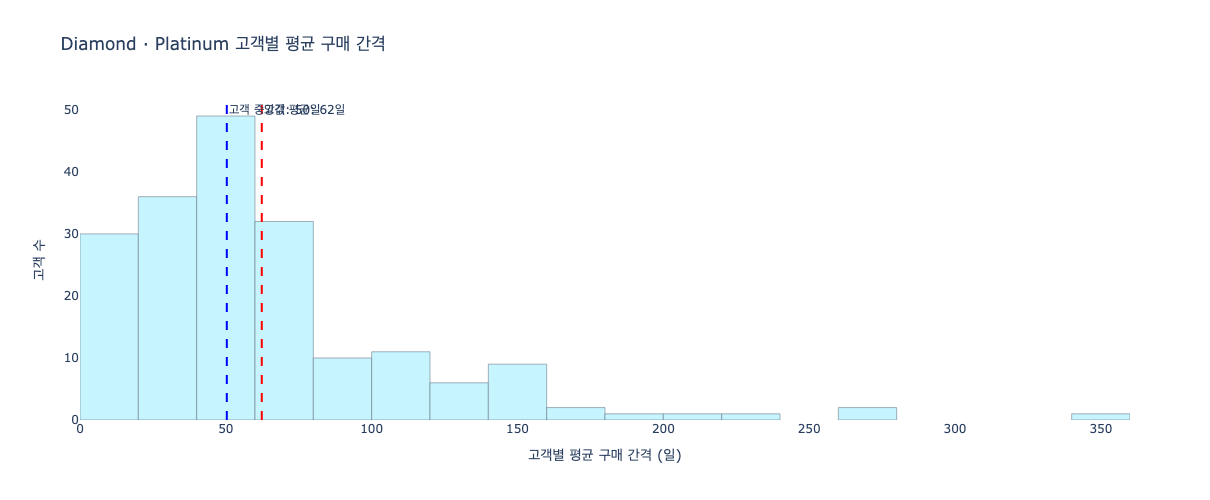

count    191.0
mean      62.3
std       52.9
min        1.0
25%       31.0
50%       50.3
75%       76.1
max      351.0
Name: 고객별_평균구매간격, dtype: float64

In [4]:
# 고객마다 구매 간격 수가 달라 이벤트 평균은 다빈도 고객에 더 큰 가중치를 준다.
# 고객별 평균 간격을 먼저 계산해 고객을 동일 가중으로 비교한다.
customer_cycle = (
    df_cycle.groupby(['고객ID', '등급'], as_index=False)['구매_사이클']
    .mean()
    .rename(columns={'구매_사이클': '고객별_평균구매간격'})
)
mean_val = customer_cycle['고객별_평균구매간격'].mean()
median_val = customer_cycle['고객별_평균구매간격'].median()

fig = go.Figure(go.Histogram(
    x=customer_cycle['고객별_평균구매간격'],
    marker=dict(color='#B9F2FF', line=dict(color='#2c3e50', width=0.5)),
    opacity=0.8, nbinsx=30,
))
fig.add_vline(x=mean_val, line_dash='dash', line_color='red', annotation_text=f'고객 평균: {mean_val:.0f}일')
fig.add_vline(x=median_val, line_dash='dash', line_color='blue', annotation_text=f'고객 중앙값: {median_val:.0f}일')
fig.update_layout(
    title='Diamond · Platinum 고객별 평균 구매 간격',
    xaxis_title='고객별 평균 구매 간격 (일)', yaxis_title='고객 수',
    plot_bgcolor='white', height=500,
)
fig.show()
customer_cycle['고객별_평균구매간격'].describe().round(1)


> **구매 간격 분석 단위**
>
> 연속 구매 간격을 그대로 평균내면 다빈도 고객이 더 큰 가중치를 갖는다. 고객별 평균
> 구매 간격을 먼저 계산해 고객을 동일 가중으로 비교한다. 월 코호트는 별도의 복귀
> 패턴을 보는 기술 분석이며 고정 구매 사이클을 검증하는 근거로만 사용하지 않는다.


---
## 데이터 로드

In [5]:
df_dp = run('dp_orders', parse_dates=['거래날짜'])

df_dp['거래월'] = df_dp['거래날짜'].dt.to_period('M')

In [6]:
print(f'행 수: {df_dp.shape[0]:,}')
print(f'고객 수: {df_dp["고객ID"].nunique():,}명')
df_dp.head()

행 수: 23,394
고객 수: 212명


,고객ID,거래ID,거래날짜,제품카테고리,세후금액,등급,거래월
0,USER_1358,Transaction_0000,2019-01-01,Nest-USA,152.17,Platinum,2019-01
1,USER_1358,Transaction_0001,2019-01-01,Nest-USA,152.17,Platinum,2019-01
2,USER_1358,Transaction_0002,2019-01-01,Office,2.02,Platinum,2019-01
3,USER_1358,Transaction_0003,2019-01-01,Apparel,103.43,Platinum,2019-01
4,USER_1358,Transaction_0003,2019-01-01,Bags,17.52,Platinum,2019-01


---
## 코호트 리텐션 분석

> **가설 1**: 연속 구매 간격 평균이 **46일(≈ +1-2개월)** 이므로, 코호트 기준 +1-2개월 시점에 재구매가 집중될 것이다.
>
> - 근거: 전체 802건 구매 간격 중 75%가 71일 이내 재구매
> - 검증: 코호트별 월 단위 리텐션 히트맵
> - 판정 기준: +1-2개월 구간의 재구매율이 다른 구간보다 일관되게 높으면 채택

In [7]:
first_month = (
    df_dp.groupby('고객ID')['거래월']
    .min()
    .reset_index()
    .rename(columns={'거래월': '코호트월'})
)
df_dp = df_dp.merge(first_month, on='고객ID', how='left')

df_dp['경과월'] = (df_dp['거래월'] - df_dp['코호트월']).apply(lambda x: x.n)

In [8]:
cohort_data = (
    df_dp.groupby(['코호트월', '경과월'])['고객ID']
    .nunique()
    .reset_index()
)
cohort_pivot = cohort_data.pivot_table(
    index='코호트월', columns='경과월', values='고객ID'
)
cohort_size = cohort_pivot.iloc[:, 0]
retention = (cohort_pivot.divide(cohort_size, axis=0) * 100).round(1)
retention

경과월,0,1,2,3,4,5,6,7,8,9,10,11
코호트월,,,,,,,,,,,,
2019-01,100.0,23.1,28.2,28.2,23.1,56.4,53.8,48.7,35.9,46.2,41.0,48.7
2019-02,100.0,14.8,11.1,29.6,29.6,37.0,37.0,22.2,25.9,33.3,37.0,NaN
2019-03,100.0,21.9,46.9,31.2,40.6,43.8,25.0,40.6,31.2,37.5,NaN,NaN
2019-04,100.0,21.1,21.1,31.6,21.1,26.3,15.8,42.1,31.6,NaN,NaN,NaN
2019-05,100.0,15.8,21.1,36.8,31.6,26.3,36.8,10.5,NaN,NaN,NaN,NaN
2019-06,100.0,50.0,16.7,25.0,16.7,41.7,33.3,NaN,NaN,NaN,NaN,NaN
2019-07,100.0,30.0,20.0,20.0,30.0,30.0,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,100.0,22.2,33.3,44.4,22.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-09,100.0,20.0,40.0,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


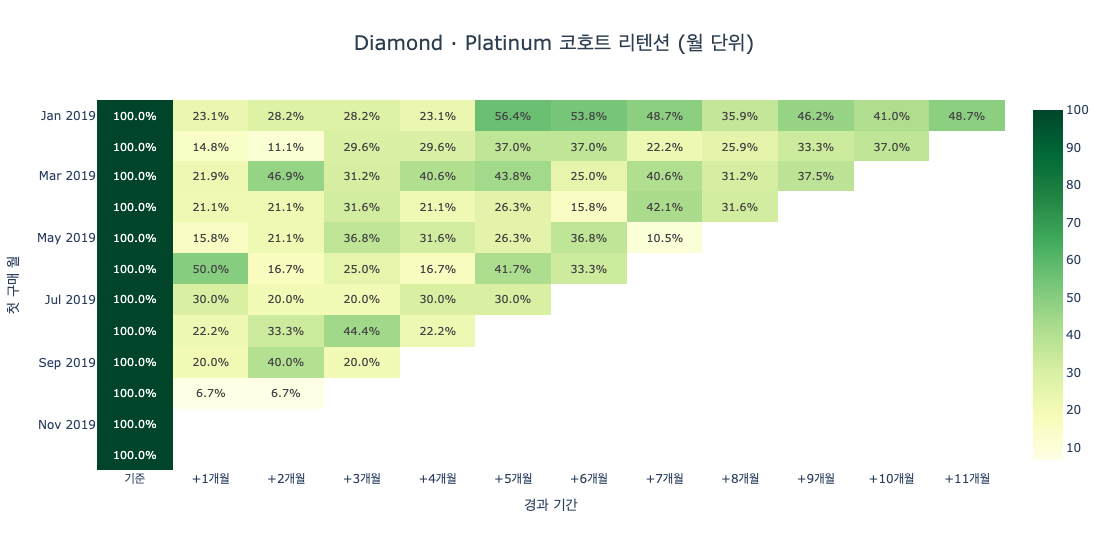

In [9]:
x_labels = ['기준' if c == 0 else f'+{c}개월' for c in retention.columns]
retention_sorted = retention.sort_index(ascending=True)

text_vals = [
    [f'{v:.1f}%' if pd.notna(v) else '' for v in row]
    for row in retention_sorted.values
]

fig = go.Figure(go.Heatmap(
    z=retention_sorted.values,
    x=x_labels,
    y=[str(i) for i in retention_sorted.index],
    colorscale='YlGn',
    text=text_vals,
    texttemplate='%{text}',
    textfont=dict(size=11),
    showscale=True
))

fig.update_layout(
    title=dict(
        text='Diamond · Platinum 코호트 리텐션 (월 단위)',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    xaxis_title='경과 기간',
    yaxis_title='첫 구매 월',
    plot_bgcolor='white',
    height=550,
    yaxis=dict(autorange='reversed')
)
fig.show()

> ### 가설 1 관찰 결과: 불일치
>
> **핵심 요약**
> 구매 사이클(평균 46.1일) 전후에 재구매가 집중된다는 패턴은 나타나지 않았다.
>
> - **현황**: 코호트별 +1개월 리텐션이 **6.7-50.0%** 로 편차가 매우 크며, 단일 패턴으로 설명되지 않는다.
> - **데이터 특징**: 사이클 표준편차(56.8일)가 평균(46.1일)보다 커, 코호트 입장 시점에 따라 재구매 분포가 분산된다.

---

> **가설 1-1** — 고정 사이클보다 **특정 달력 월 집중**이 더 뚜렷할 것이다.
>
> - 근거: Diamond·Platinum은 RFM 고점 고객으로 반복 구매 패턴이 이미 내재화되어 있을 가능성이 높음
> - 검증: 월별 거래 건수·금액·재방문율 확인

---
## 월별 거래 현황

In [10]:
monthly_stats = (
    df_dp.groupby(df_dp['거래월'].astype(str))
    .agg(
        거래건수=('거래ID', 'nunique'),
        거래금액=('세후금액', 'sum')
    )
    .reset_index()
    .rename(columns={'거래월': '월'})
)
monthly_stats['거래금액'] = monthly_stats['거래금액'].round(0)
monthly_stats

,월,거래건수,거래금액
0,2019-01,738,152642.0
1,2019-02,723,132956.0
2,2019-03,713,127326.0
3,2019-04,725,224113.0
4,2019-05,902,138462.0
5,2019-06,698,121823.0
6,2019-07,1029,208130.0
7,2019-08,975,171395.0
8,2019-09,885,166151.0
9,2019-10,1322,266520.0


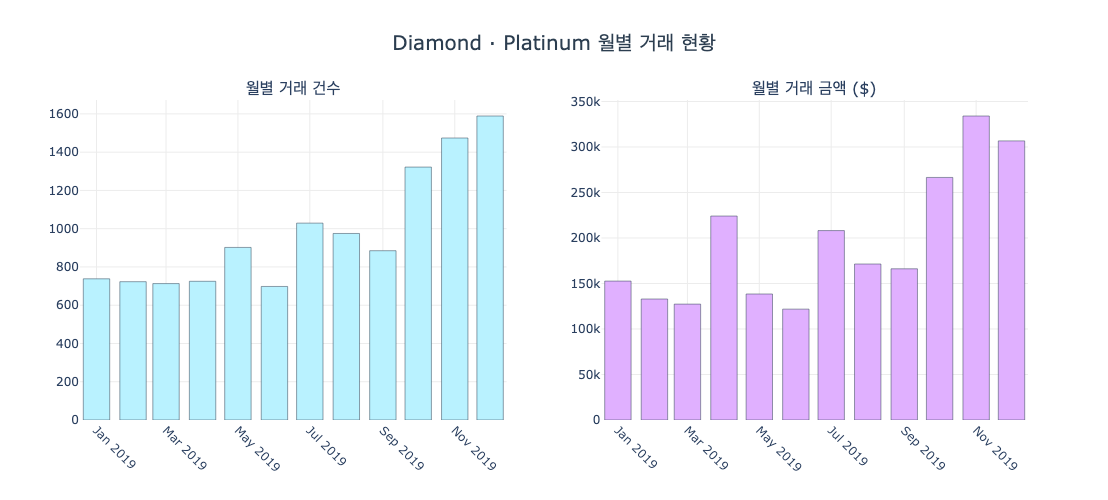

In [11]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['월별 거래 건수', '월별 거래 금액 ($)']
)

fig.add_trace(
    go.Bar(
        x=monthly_stats['월'],
        y=monthly_stats['거래건수'],
        marker=dict(color='#B9F2FF', line=dict(color='#2c3e50', width=0.5)),
        showlegend=False
    ),
    row=1, col=1
)
fig.add_trace(
    go.Bar(
        x=monthly_stats['월'],
        y=monthly_stats['거래금액'],
        marker=dict(color='#E0B0FF', line=dict(color='#2c3e50', width=0.5)),
        showlegend=False
    ),
    row=1, col=2
)

fig.update_layout(
    title=dict(
        text='Diamond · Platinum 월별 거래 현황',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    height=500,
    plot_bgcolor='white'
)
fig.update_xaxes(gridcolor='#ececec', tickangle=45)
fig.update_yaxes(gridcolor='#ececec')
fig.show()

---
## 월별 재방문율

코호트별 월 단위 리텐션을 계산한 뒤, 동일 달력 월에 해당하는 재방문율을 평균내어  
실제 구매 월 기준 재방문율 트렌드를 확인한다.

In [12]:
cohort_data_m = (
    df_dp.groupby(['코호트월', '경과월'])['고객ID']
    .nunique()
    .reset_index()
)
cohort_pivot_m = cohort_data_m.pivot_table(
    index='코호트월', columns='경과월', values='고객ID'
)
cohort_size_m = cohort_pivot_m.iloc[:, 0]
retention_m = (cohort_pivot_m.divide(cohort_size_m, axis=0) * 100).round(1)

actual_data = []
for cohort in retention_m.index:
    for month_idx in retention_m.columns:
        value = retention_m.loc[cohort, month_idx]
        if pd.notna(value) and month_idx > 0:
            actual_data.append({
                '실제구매월': str(cohort + month_idx),
                '재방문율': value
            })

monthly_revisit = (
    pd.DataFrame(actual_data)
    .groupby('실제구매월')['재방문율']
    .mean()
    .round(1)
    .reset_index()
    .rename(columns={'실제구매월': '월', '재방문율': '평균_재방문율(%)'})
    .sort_values('월')
)
monthly_revisit

,월,평균_재방문율(%)
0,2019-02,23.1
1,2019-03,21.5
2,2019-04,20.4
3,2019-05,30.2
4,2019-06,30.8
5,2019-07,39.0
6,2019-08,33.4
7,2019-09,26.0
8,2019-10,27.2
9,2019-11,34.7


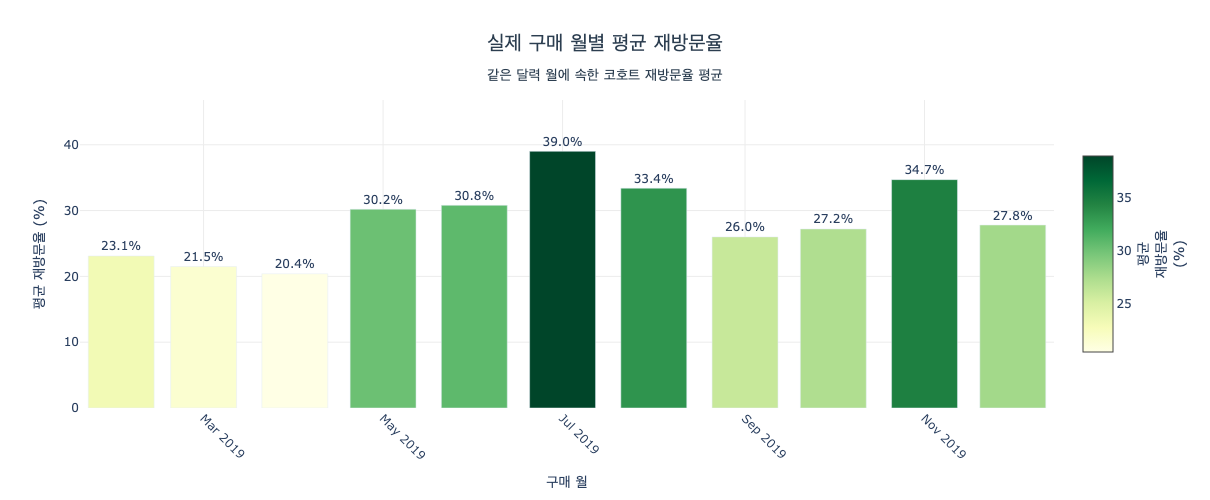

In [13]:
fig = go.Figure(go.Bar(
    x=monthly_revisit['월'],
    y=monthly_revisit['평균_재방문율(%)'],
    marker=dict(
        color=monthly_revisit['평균_재방문율(%)'],
        colorscale='YlGn',
        showscale=True,
        colorbar=dict(title=dict(text='평균<br>재방문율<br>(%)', side='right'), len=0.7)
    ),
    text=monthly_revisit['평균_재방문율(%)'].apply(lambda x: f'{x:.1f}%'),
    textposition='outside'
))

fig.update_layout(
    title=dict(
        text='실제 구매 월별 평균 재방문율<br><sub>같은 달력 월에 속한 코호트 재방문율 평균</sub>',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    xaxis=dict(title='구매 월', gridcolor='#ececec', tickangle=45),
    yaxis=dict(
        title='평균 재방문율 (%)',
        gridcolor='#ececec',
        range=[0, monthly_revisit['평균_재방문율(%)'].max() * 1.2]
    ),
    plot_bgcolor='white',
    height=500
)
fig.show()

> ### 가설 1-1 관찰 결과: 일치 (해석 단서 필요)
>
> **핵심 요약**
> 거래 건수·금액의 하반기 집중과 재방문율 피크가 일치해 달력 월 집중이 관찰된다. 단, 합성 데이터 특성상 다년도 재검증이 필요하다.
>
> - **현황**: 거래 건수·금액이 **7월(1,029건), 11월(1,474건), 12월(1,589건)** 에 집중, 하반기로 갈수록 증가한다.
> - **재방문율**: 월별 평균 재방문율 **7월(39.0%)** 이 연중 최고, **11월(34.7%)** 이 뒤를 이으며 달력 월 집중이 관찰된다.
> - **해석 단서**: 본 데이터는 합성 데이터이므로 7월 피크가 실제 계절성을 반영하는지 불확실하다. **1년치 데이터로는 달력 월 집중의 반복 여부를 검증할 수 없으며**, 실제 적용 전 다년도 데이터 재검증이 필요하다.

---
## 가설 2 — 등급별 구매 패턴 차이

> **가설 2**: Diamond는 쿠폰 없이도 재구매하지만 Platinum은 쿠폰 의존도가 높을 것이다.  
> 나아가 두 등급은 주요 구매 카테고리 구성도 다를 것이다.
>
> - 근거: Diamond(RFM ≥ 95)는 Platinum(RFM ≥ 80)보다 구매 충성도가 내재화된 고객군
> - 검증: 등급별 쿠폰 사용률 + 카테고리 분포 비교
> - 판정 기준: Diamond의 쿠폰 사용률이 낮고 카테고리 구성이 Platinum과 다르면 채택

In [14]:
coupon_tx = run('coupon_by_grade')

coupon_tx['쿠폰_사용률(%)'] = (coupon_tx['쿠폰_거래수'] / coupon_tx['총_거래수'] * 100).round(1)
coupon_tx

,등급,쿠폰_거래수,총_거래수,쿠폰_사용률(%)
0,Platinum,3131.0,6575,47.6
1,Diamond,2549.0,5360,47.6


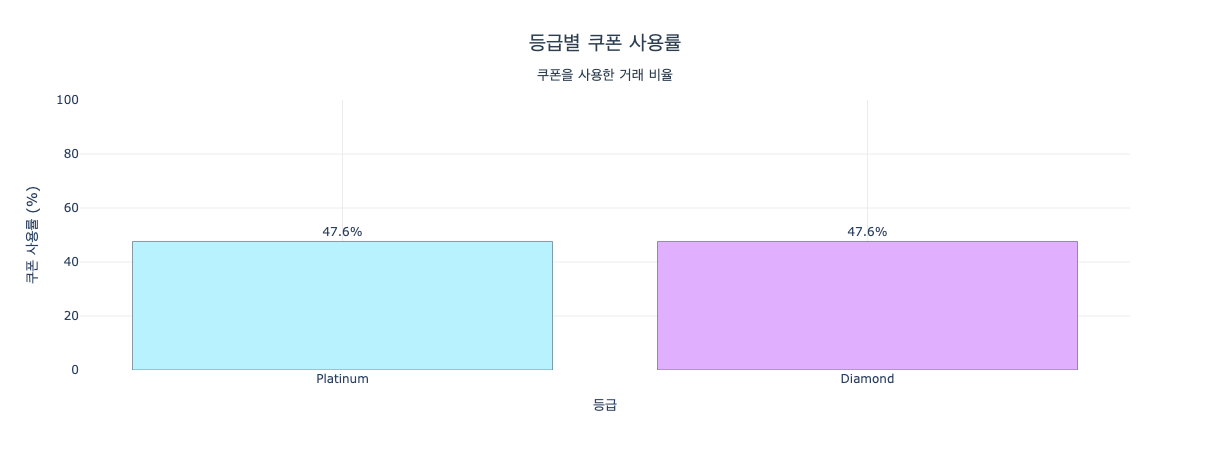

In [15]:
fig = go.Figure(go.Bar(
    x=coupon_tx['등급'],
    y=coupon_tx['쿠폰_사용률(%)'],
    marker=dict(
        color=['#B9F2FF', '#E0B0FF'],
        line=dict(color='#2c3e50', width=0.5)
    ),
    text=coupon_tx['쿠폰_사용률(%)'].apply(lambda x: f'{x:.1f}%'),
    textposition='outside'
))

fig.update_layout(
    title=dict(
        text='등급별 쿠폰 사용률<br><sub>쿠폰을 사용한 거래 비율</sub>',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    xaxis=dict(title='등급', gridcolor='#ececec'),
    yaxis=dict(title='쿠폰 사용률 (%)', gridcolor='#ececec', range=[0, 100]),
    plot_bgcolor='white',
    width=350,
    height=450
)
fig.show()

In [16]:
# 카테고리별 쿠폰 사용 비율 (통계적 신뢰도 확보를 위해 거래 100건 초과 카테고리만 포함)
cat_coupon = run('coupon_by_category')

cat_coupon['쿠폰_사용률(%)'] = (cat_coupon['쿠폰사용_건수'] / cat_coupon['총_건수'] * 100).round(1)
cat_coupon

,등급,제품카테고리,쿠폰사용_건수,총_건수,쿠폰_사용률(%)
0,Platinum,Nest-USA,1111.0,3017,36.8
1,Diamond,Nest-USA,901.0,2368,38.0
2,Platinum,Apparel,1017.0,1950,52.2
3,Diamond,Apparel,865.0,1716,50.4
4,Platinum,Office,400.0,860,46.5
5,Diamond,Office,339.0,720,47.1
6,Platinum,Nest,256.0,697,36.7
7,Platinum,Drinkware,234.0,591,39.6
8,Diamond,Nest,180.0,538,33.5
9,Diamond,Drinkware,227.0,514,44.2


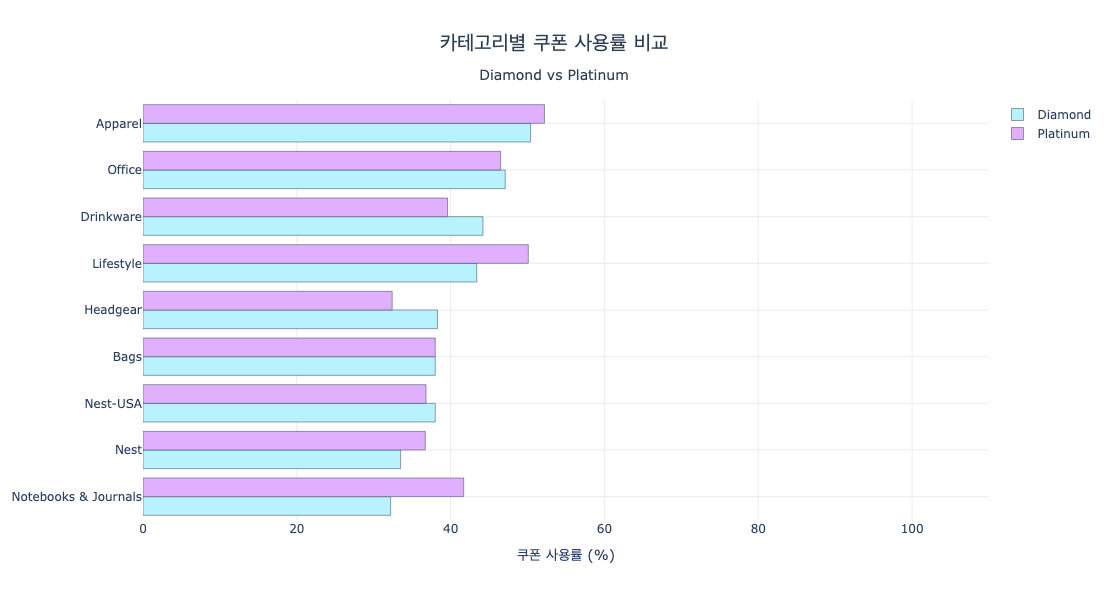

In [17]:
diamond_c = (
    cat_coupon[cat_coupon['등급'] == 'Diamond'][['제품카테고리', '쿠폰_사용률(%)']]
    .rename(columns={'쿠폰_사용률(%)': 'Diamond'})
)
platinum_c = (
    cat_coupon[cat_coupon['등급'] == 'Platinum'][['제품카테고리', '쿠폰_사용률(%)']]
    .rename(columns={'쿠폰_사용률(%)': 'Platinum'})
)
cat_coupon_compare = (
    diamond_c.merge(platinum_c, on='제품카테고리')
    .sort_values('Diamond', ascending=True)
)

fig = go.Figure()
fig.add_trace(go.Bar(
    y=cat_coupon_compare['제품카테고리'],
    x=cat_coupon_compare['Diamond'],
    name='Diamond',
    orientation='h',
    marker=dict(color='#B9F2FF', line=dict(color='#2c3e50', width=0.5))
))
fig.add_trace(go.Bar(
    y=cat_coupon_compare['제품카테고리'],
    x=cat_coupon_compare['Platinum'],
    name='Platinum',
    orientation='h',
    marker=dict(color='#E0B0FF', line=dict(color='#2c3e50', width=0.5))
))

fig.update_layout(
    title=dict(
        text='카테고리별 쿠폰 사용률 비교<br><sub>Diamond vs Platinum</sub>',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    xaxis=dict(title='쿠폰 사용률 (%)', gridcolor='#ececec', range=[0, 110]),
    yaxis=dict(gridcolor='#ececec'),
    barmode='group',
    legend=dict(orientation='v', x=1.01, y=1),
    plot_bgcolor='white',
    height=600
)
fig.show()

> ### 가설 2 관찰 결과: 불일치
>
> **핵심 요약**
> 쿠폰 사용률이 두 등급 간 동일해, 관찰 데이터에서 두 등급의 전체 쿠폰 사용률 차이가 보이지 않는다.
>
> - **현황**: 전체 쿠폰 사용률 Diamond **47.6%** vs Platinum **47.6%** — 차이 **0%p**
> - **비즈니스 시사점**: 두 등급 모두 거래의 약 **48%** 에 쿠폰을 사용하면서도 충성도 차이가 존재한다. 즉, **등급 배지·전용 혜택** 등 쿠폰 외 요인이 두 등급을 가르는 주요 요인임을 시사한다.

---
## 가설 3 — Platinum 이탈 조짐 고객 식별

> **가설 3**: Platinum 중 마지막 구매가 오래된 고객(이탈 조짐)은 일반 Platinum과 구매 패턴이 다를 것이다.
>
> - 정의: Recency > 90일 = 이탈 조짐 고객 (2019-12-31 기준)
> - 근거: rfm_segmentation에서 Platinum 내 이탈 위험·놓치면 안될 고객이 약 7% 존재
> - 검증: 이탈 조짐 그룹 vs 일반 그룹의 Recency, 구매 빈도, 총 구매금액 비교
> - 판정 기준: 이탈 조짐 고객이 일반 Platinum과 구매 빈도·금액에서 뚜렷한 차이를 보이면 채택

In [18]:
plat_recency = run('platinum_recency')

plat_recency['위험군'] = plat_recency['Recency'].apply(
    lambda x: '이탈 조짐 (>90일)' if x > 90 else '일반 Platinum'
)

churn_compare = (
    plat_recency.groupby('위험군')[['Recency', '구매일수', '총구매금액']]
    .agg(["mean", "median"])
    .round(1)
)
churn_compare

Recency        구매일수           총구매금액         
                mean median mean median     mean   median
위험군                                                      
이탈 조짐 (>90일)   139.1  121.0  5.0    4.0  13801.3  10653.0
일반 Platinum     40.4   38.0  3.7    3.0   7279.5   6745.0

In [19]:
max_gap_plat = run('max_gap_platinum')

plat_recency = plat_recency.merge(max_gap_plat, on='고객ID', how='left')
plat_recency['최대구매간격'] = plat_recency['최대구매간격'].fillna(0).astype(int)

plat_recency['위험군'] = plat_recency.apply(
    lambda x: '이탈 조짐 (>90일)' if x['Recency'] > 90
    else ('이탈 후 복귀' if x['최대구매간격'] > 90 else '일반 Platinum'),
    axis=1
)

total_plat = len(plat_recency)
for 구분 in ['일반 Platinum', '이탈 후 복귀', '이탈 조짐 (>90일)']:
    n = int((plat_recency['위험군'] == 구분).sum())
    print(f"{구분}: {n}명 ({n/total_plat*100:.1f}%)")

churn_compare = (
    plat_recency.groupby('위험군')[['Recency', '구매일수', '총구매금액']]
    .agg(['mean', 'median'])
    .round(1)
)
churn_compare

일반 Platinum: 49명 (31.8%)
이탈 후 복귀: 72명 (46.8%)
이탈 조짐 (>90일): 33명 (21.4%)


Recency        구매일수           총구매금액         
                mean median mean median     mean   median
위험군                                                      
이탈 조짐 (>90일)   139.1  121.0  5.0    4.0  13801.3  10653.0
이탈 후 복귀         36.4   34.0  4.4    4.0   7737.0   7493.5
일반 Platinum     46.2   51.0  2.8    2.0   6607.2   6024.0

In [20]:
plat_recency['위험군'].value_counts()

위험군
이탈 후 복귀         72
일반 Platinum     49
이탈 조짐 (>90일)    33
Name: count, dtype: int64

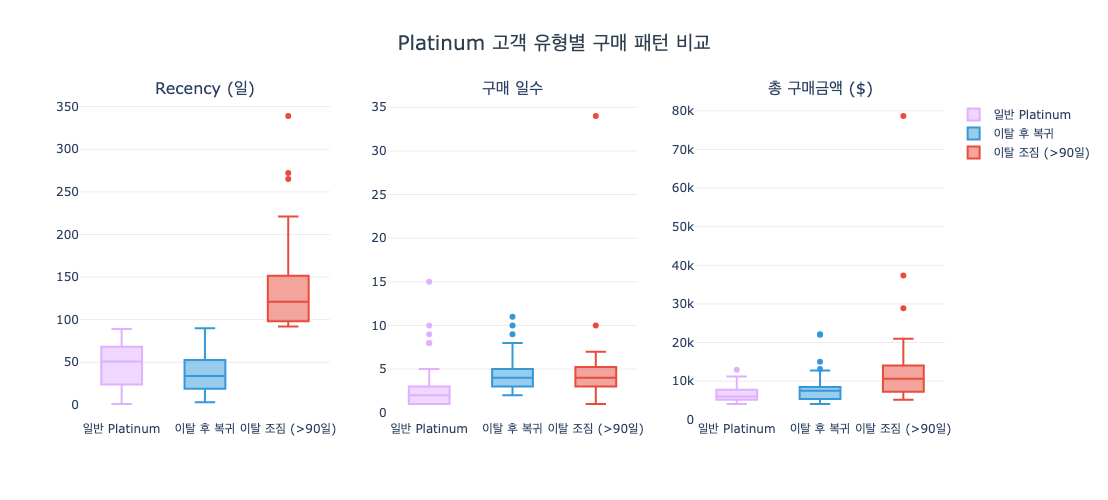

In [21]:
metrics = ['Recency', '구매일수', '총구매금액']
metric_titles = ['Recency (일)', '구매 일수', '총 구매금액 ($)']
colors_risk = {'이탈 조짐 (>90일)': '#e74c3c', '이탈 후 복귀': '#3498db', '일반 Platinum': '#E0B0FF'}

fig = make_subplots(rows=1, cols=3, subplot_titles=metric_titles)

groups = ['일반 Platinum', '이탈 후 복귀', '이탈 조짐 (>90일)']
for col_idx, metric in enumerate(metrics, 1):
    for group in groups:
        sub = plat_recency[plat_recency['위험군'] == group][metric]
        fig.add_trace(
            go.Box(
                y=sub,
                name=group,
                marker_color=colors_risk.get(group, '#95a5a6'),
                showlegend=(col_idx == 1)
            ),
            row=1, col=col_idx
        )

fig.update_layout(
    title=dict(
        text='Platinum 고객 유형별 구매 패턴 비교',
        font=dict(size=20, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    plot_bgcolor='white',
    height=500,
    legend=dict(orientation='v', x=1.01, y=1)
)
fig.update_yaxes(gridcolor='#ececec')
fig.show()

### 가설 3 관찰 결과: 일치 (예상과 다른 발견)

| 지표 | 이탈 조짐 (>90일) | 이탈 후 복귀 | 일반 Platinum |
|------|:---:|:---:|:---:|
| 인원 | 33명 (21.4%) | 72명 (46.8%) | 49명 (31.8%) |
| Recency 중앙값 | **121일** | 34일 | 51일 |
| 구매 일수 중앙값 | 4일 | 4일 | 2일 |
| 총구매금액 중앙값 | **`$10,653`** | `$7,494` | `$6,024` |

**핵심 요약**
이탈 조짐 고객의 누적 구매금액이 일반 Platinum보다 높다. 과거 고가치 고객이 최근 침묵한 상태로, **선제적 재참여 우선순위가 높은 고객군**이다.

- **예상과 다른 발견**: 이탈 조짐 총구매금액 중앙값(`$10,653`) > 이탈 후 복귀(`$7,494`) > 일반 Platinum(`$6,024`)
- **구조적 특성**: Platinum 고객 **3명 중 2명(68.2%, 105/154명)** 이 연중 장기 공백 경험 — 이탈은 예외가 아닌 구조적 패턴
- **시사점**: 고가치 장기 미방문 고객은 재참여 실험의 우선 후보지만, 신규 획득 대비 비용 효율은 비용·마진 데이터로 검증해야 함

---
## 가설 4 — 관측기간 첫 구매 카테고리와 같은 해 최종 상위 등급은 연관성이 있다

> **가설 4**: 특정 카테고리로 첫 구매를 시작한 고객이 Diamond·Platinum으로 전환될 가능성이 더 높을 것이다.
>
> - 근거: 첫 구매 카테고리는 고객의 초기 구매력과 관심사를 반영 — 고가 카테고리 진입 고객이 상위 등급으로 이어질 가능성이 높음
> - 검증 ①: 전체 고객 vs Diamond·Platinum의 첫 구매 카테고리 분포 비교 (**단순 비율이 아닌 전체 평균 대비 얼마나 집중되어 있는지 확인**)
> - 검증 ②: 카테고리별 Diamond·Platinum 최종 D·P 비율 — 분모를 전체 1,468명 기준으로 설정
> - 판정 기준: 첫 구매 카테고리별 같은 해 최종 D·P 비율 차이가 뚜렷하면 채택

In [22]:
first_cat = run('first_category')
first_cat.head()

,고객ID,첫_카테고리,등급
0,USER_0000,Apparel,Bronze
1,USER_0001,Apparel,Platinum
2,USER_0002,Nest-USA,Bronze
3,USER_0003,Nest-USA,Silver
4,USER_0004,Nest-USA,Silver


In [23]:
# 카테고리별 전체·DP 고객수는 SQL(first_category_agg), 비율·차이는 Python
agg = run('first_category_agg')
agg['전체_고객수'] = agg['전체_고객수'].astype(int)
agg['DP_고객수'] = agg['DP_고객수'].astype(int)

dist_compare = agg.copy()
dist_compare['전체_비율(%)'] = (dist_compare['전체_고객수'] / dist_compare['전체_고객수'].sum() * 100).round(1)
dist_compare['DP_비율(%)'] = (dist_compare['DP_고객수'] / dist_compare['DP_고객수'].sum() * 100).round(1)
dist_compare['비율차이(%p)'] = (dist_compare['DP_비율(%)'] - dist_compare['전체_비율(%)']).round(1)
dist_compare = dist_compare[['첫_카테고리', '전체_고객수', '전체_비율(%)', 'DP_고객수', 'DP_비율(%)', '비율차이(%p)']]
dist_compare = dist_compare.sort_values('비율차이(%p)', ascending=False).reset_index(drop=True)
dist_compare = dist_compare[dist_compare['전체_고객수'] >= 30].reset_index(drop=True) # 데이터의 신뢰도 확보를 위해서 전체 고객수가 30명 미만인 카테고리는 삭제
dist_compare

,첫_카테고리,전체_고객수,전체_비율(%),DP_고객수,DP_비율(%),비율차이(%p)
0,Nest-USA,967,65.9,161,75.9,10.0
1,Office,68,4.6,10,4.7,0.1
2,Nest,58,4.0,7,3.3,-0.7
3,Drinkware,52,3.5,5,2.4,-1.1
4,Apparel,226,15.4,20,9.4,-6.0


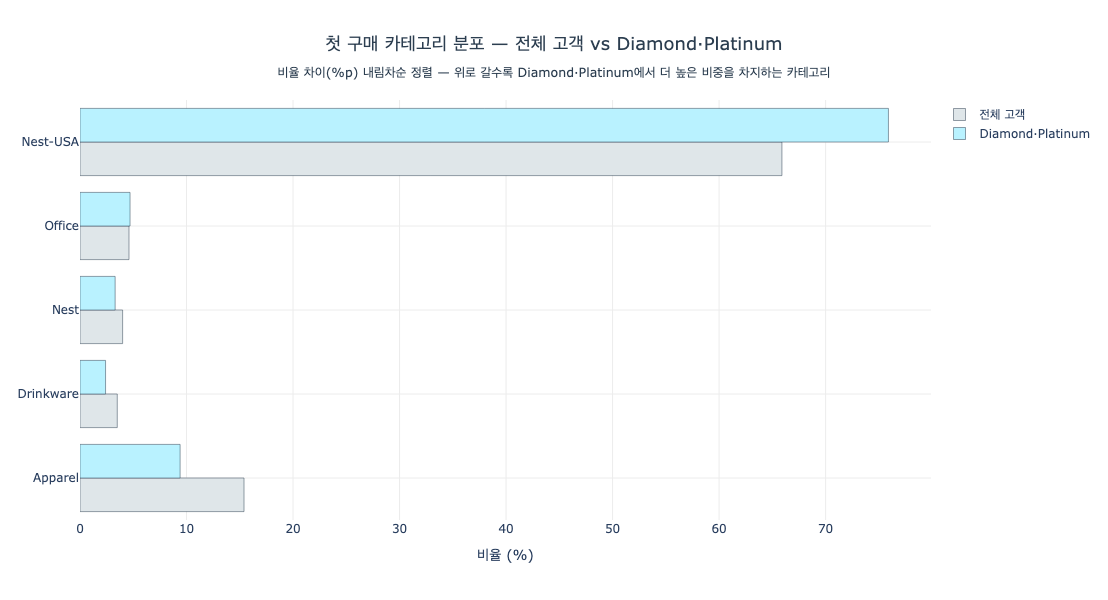

In [24]:
cat_order = dist_compare['첫_카테고리'].tolist()
total_pct = dist_compare.set_index('첫_카테고리')['전체_비율(%)']
dp_pct = dist_compare.set_index('첫_카테고리')['DP_비율(%)']

fig = go.Figure()
fig.add_trace(go.Bar(
    y=cat_order[::-1],
    x=[total_pct[c] for c in cat_order[::-1]],
    name='전체 고객',
    orientation='h',
    marker=dict(color='#dfe6e9', line=dict(color='#2c3e50', width=0.5))
))
fig.add_trace(go.Bar(
    y=cat_order[::-1],
    x=[dp_pct[c] for c in cat_order[::-1]],
    name='Diamond·Platinum',
    orientation='h',
    marker=dict(color='#B9F2FF', line=dict(color='#2c3e50', width=0.5))
))

fig.update_layout(
    title=dict(
        text='첫 구매 카테고리 분포 — 전체 고객 vs Diamond·Platinum<br><sub>비율 차이(%p) 내림차순 정렬 — 위로 갈수록 Diamond·Platinum에서 더 높은 비중을 차지하는 카테고리</sub>',
        font=dict(size=18, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    xaxis=dict(title='비율 (%)', gridcolor='#ececec'),
    yaxis=dict(gridcolor='#ececec'),
    barmode='group',
    legend=dict(orientation='v', x=1.01, y=1),
    plot_bgcolor='white',
    height=600
)
fig.show()

In [25]:
# 전환율(DP/전체)도 동일 집계(first_category_agg) 위에서 계산
conversion = run('first_category_agg')
conversion['전체_고객수'] = conversion['전체_고객수'].astype(int)
conversion['DP_고객수'] = conversion['DP_고객수'].astype(int)
conversion['전환율(%)'] = (conversion['DP_고객수'] / conversion['전체_고객수'] * 100).round(1)
conversion = conversion[['첫_카테고리', '전체_고객수', 'DP_고객수', '전환율(%)']]
conversion = conversion.sort_values('전환율(%)', ascending=False).reset_index(drop=True)
conversion = conversion[conversion['전체_고객수'] >= 30].reset_index(drop=True)
conversion

,첫_카테고리,전체_고객수,DP_고객수,전환율(%)
0,Nest-USA,967,161,16.6
1,Office,68,10,14.7
2,Nest,58,7,12.1
3,Drinkware,52,5,9.6
4,Apparel,226,20,8.8


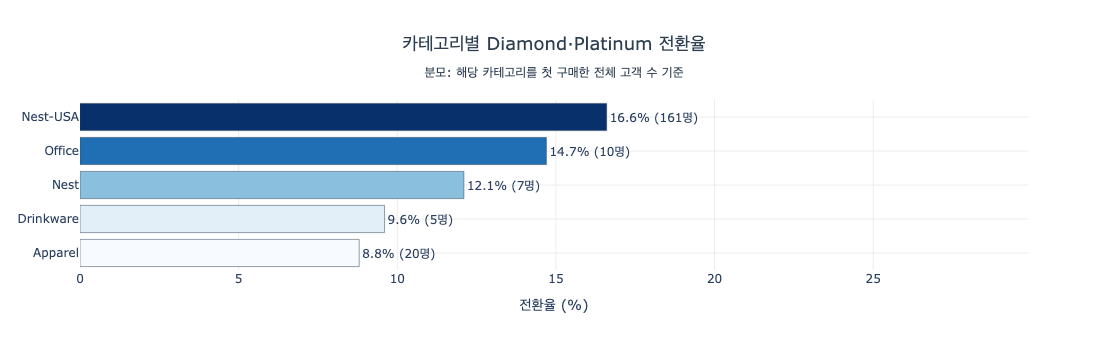

In [26]:
xmax = conversion['전환율(%)'].max() * 1.8

fig = go.Figure(go.Bar(
    y=conversion['첫_카테고리'][::-1],
    x=conversion['전환율(%)'][::-1],
    orientation='h',
    marker=dict(
        color=conversion['전환율(%)'][::-1],
        colorscale='Blues',
        showscale=False,
        line=dict(color='#2c3e50', width=0.5)
    ),
    text=(
        conversion
        .apply(lambda r: f"{r['전환율(%)']:.1f}% ({int(r['DP_고객수'])}명)", axis=1)
        [::-1]
        .values
    ),
    textposition='outside'
))

fig.update_layout(
    title=dict(
        text='카테고리별 Diamond·Platinum 전환율<br><sub>분모: 해당 카테고리를 첫 구매한 전체 고객 수 기준</sub>',
        font=dict(size=18, color='#2c3e50'), x=0.5, xanchor='center'
    ),
    xaxis=dict(title='전환율 (%)', gridcolor='#ececec', range=[0, xmax]),
    yaxis=dict(gridcolor='#ececec'),
    plot_bgcolor='white',
    height=350
)
fig.show()

### 가설 4 관찰 결과: 일치 (카테고리별 최종 D·P 비율 최대 약 1.7배 차이)

**검증 ①** — 첫 구매 카테고리 분포 비교 (전체 30명 이상 카테고리 기준)

| 카테고리 | 전체 비율 | D·P 비율 | 비율 차이 |
|---------|:-------:|:-------:|:-------:|
| Nest-USA | 65.9% | 75.9% | **+10.0%p** |
| Office | 4.6% | 4.7% | +0.1%p |
| Drinkware | 3.5% | 2.4% | -1.1%p |
| Nest | 4.0% | 3.3% | -0.7%p |
| Apparel | 15.4% | 9.4% | **-6.0%p** |

**검증 ②** — 카테고리별 같은 해 최종 D·P 비율

| 카테고리 | 전체 고객 | D·P 전환 | 최종 D·P 비율 |
|---------|:-------:|:-------:|:----:|
| Nest-USA | 967명 | 161명 | **16.6%** |
| Office | 68명 | 10명 | **14.7%** |
| Nest | 58명 | 7명 | 12.1% |
| Drinkware | 52명 | 5명 | 9.6% |
| Apparel | 226명 | 20명 | 8.8% |

**핵심 요약**
첫 구매 카테고리에 따라 같은 해 최종 D·P 비율이 최대 1.7배 차이난다.

- **최종 D·P 비율 최고**: Nest-USA(16.6%) · Office(14.7%) — 같은 해 최종 D·P 비율이 높게 관찰됨
- **최종 D·P 비율 최저**: Apparel(8.8%) — 전체 첫 구매 2위(15.4%)임에도 D·P 비중은 오히려 낮음(-6.0%p)
- **단서**: Nest-USA 쏠림이 매우 강해(전체 967명) 카테고리 간 절대 표본 크기 차이가 있어 비교에 한계가 있음

---
## 결론 및 핵심 인사이트

Diamond·Platinum은 전체 고객의 **14.44%**, 매출 **48.56%** 를 담당하는 최상위 고객군이다. Diamond(재방문율 95%)·Platinum(88%)은 높은 충성도를 보이지만, Platinum의 **68.2%** 가 연중 장기 공백을 경험하는 구조적 이탈 위험이 공존한다.

### 발견 1 — 고정 구매 사이클은 보이지 않고 특정 달력 월에 거래가 집중된다 _(가설 1·1-1)_

코호트별 +1개월 리텐션이 6.7-50.0%로 편차가 커 구매 사이클 기반 가설은 기각. **특정 달력 월에 거래가 집중**한다.

- **피크 패턴**: 거래 건수·금액이 7월(1,029건)·11월(1,474건)·12월(1,589건)에 집중, 재방문율도 **7월(39.0%)** 이 연중 최고
- **캠페인 시사점**: 피크 전 접촉은 검증할 실험 후보 — 7월·11-12월 달력 월 집중 구간 실험 (최적 리드타임은 A/B 테스트로 검증)
- **한계**: 합성 데이터로 7월 피크의 실제 계절성 여부 불확실, 다년도 데이터 재검증 필요

### 발견 2 — 쿠폰 의존도는 등급을 가르지 않는다 _(가설 2)_

Diamond·Platinum 쿠폰 사용률 **동일(47.6%)** — 관찰 데이터에서 두 등급의 전체 쿠폰 사용률 차이가 보이지 않았다.

- **데이터**: 카테고리별(Apparel·Nest-USA·Office)로도 두 등급 간 차이 없음
- **시사점**: 두 등급을 가르는 레버리지는 쿠폰이 아닌 **등급 배지·전용 혜택** — 등급 차별화 경험을 쿠폰과 비교 실험할 수 있음

### 발견 3 — 이탈 조짐 Platinum이 재참여 우선순위가 높은 고객군이다 _(가설 3)_

Platinum 고객 **68.2%(105/154명)** 가 연중 장기 공백 경험. 이탈 조짐 고객(33명)은 예상과 달리 가장 높은 구매가치를 보유한다.

- **예상과 다른 패턴**: 이탈 조짐 총구매금액 중앙값(`$10,653`) > 이탈 후 복귀(`$7,494`) > 일반 Platinum(`$6,024`)
- **시사점**: 고가치 장기 미방문 고객은 재참여 실험의 우선 후보지만, 신규 획득 대비 비용 효율은 비용·마진 데이터로 검증해야 함 — **개인화 재참여 실험 우선 검토**

### 발견 4 — 관측기간 첫 구매 카테고리와 같은 해 최종 상위 등급은 연관성이 있다 _(가설 4)_

카테고리별 같은 해 최종 D·P 비율이 최대 1.7배 차이난다(Nest-USA 16.6% · Office 14.7% vs Apparel 8.8%).

- **전환 최고**: Nest-USA·Office — 같은 해 최종 D·P 비율이 높게 관찰됨, 유입 우선 타겟
- **전환 최저**: Apparel — 전체 첫 구매 2위임에도 D·P 비중 낮음, 조기 크로스셀링으로 카테고리 다각화 유도
- **한계**: Nest-USA 쏠림이 매우 강해(전체 967명) 카테고리 간 절대 표본 크기 차이가 있어 비교에 한계가 있음

> **액션 아이템**
>
> **Diamond 대상**
> - **1**. **"이번 달도 Diamond 등급 유지 중 — 전용 혜택을 확인하세요"** 혜택 강조 알림 발송
> - **2**. 할인 이벤트 **24시간 전 얼리 액세스** 제공으로 VIP 경험 강화
> - **3**. 시즌 피크(7월, 11월) **사전** 시즌 예고 알림 발송 — 리드타임은 A/B 테스트로 검증 (가설 1-1 기반)
>
> **Platinum 대상**
> - **1**. **"Platinum → Diamond까지 $XX 남았습니다"** 등급 전환 알림
> - **2**. 등급 상승 시 즉시 보상 제공으로 재구매 동기 부여
> - **3**. Recency > 90일 이탈 조짐 고객(**33명**, 가설 3) → 과거 구매 품목 기반 맞춤형 재참여 캠페인 우선 집행
>
> **Diamond + Platinum 공통**
> - **1**. 시즌 피크(7월, 11-12월) 집중 캠페인 기획 (가설 1-1 기반)
> - **2**. 관측기간 첫 구매 시 **Nest-USA·Office 카테고리 유입 우선** — 같은 해 최종 D·P 비율 14.7-16.6% (가설 4 기반)
> - **3**. Apparel 첫 구매 고객(최종 D·P 비율 8.8%)은 **조기 크로스셀링**으로 Nest-USA·Office 카테고리로 유도
> - **4**. 쿠폰 의존도가 두 등급 간 동질적(가설 2)이므로 → 쿠폰 혜택보다 **등급 배지·전용 혜택**으로 차별화

> **A/B 테스트 제안**
>
> "원본 A를 대안 B로 바꾸면 목표 지표가 개선될 것이다"를 가설로, 핵심 지표·가드레일·기간·분석 방법을 사전에 고정한다. 세그먼트 규모가 작아 개별 A/B의 통계 검정력은 제한적이므로, 실제 집행 시 표본 크기·기간은 운영 로그로 산정하고 여기서는 무엇을·어떤 지표로 검증할지 설계에 집중한다.
>
> **공통 설계 기준**
> - **실험 단위**: 고객 ID 단위 랜덤 배정(해시 기반), 동일 고객의 복수 실험 동시 노출 배제
> - **가드레일 지표**: 수신 거부율·할인 비용률·AOV — 핵심 지표가 개선돼도 가드레일이 비열등성 마진(NIM)을 벗어나면 롤백
> - **분석·판단**: 표본이 작으면 Fisher exact test 또는 더 넓은 적격 모집단으로 판단하고, 단순 수치 비교·조기 중지는 금지하며 계절성 구간을 통제한다
>
> ---
>
> **실험 1 — Diamond: 혜택 강조 알림 vs 일반 프로모션 (58명)**
> - **가설**: 혜택 강조 알림(B)이 일반 프로모션(A)보다 재구매 동기를 더 자극할 것이다
> - **그룹**: A = 일반 할인 프로모션 알림 / B = "이번 달도 Diamond 등급 유지 중 — 전용 혜택 확인" 알림
> - **핵심 지표**: 발송 후 30일 내 재구매율 / **보조 지표**: AOV, ARPU
> - **기간**: 최소 4주
>
> **실험 2 — Platinum 이탈 조짐: 개인화 재참여 vs 일반 쿠폰 (33명)**
> - **가설**: 과거 구매 품목 기반 맞춤형 재참여 메시지(B)가 일반 쿠폰(A)보다 재구매율을 높일 것이다
> - **그룹**: A = 일반 할인 쿠폰 / B = 구매 이력 기반 맞춤형 재참여 메시지
> - **핵심 지표**: 발송 후 60일 내 재구매율 / **보조 지표**: AOV, ARPU
> - **기간**: 최소 8주
>
> **실험 3 — 공통: 시즌 피크 조기 타겟팅 (212명)**
> - **가설**: 시즌 피크 3-4주 전 얼리버드 알림(B)이 기존 커뮤니케이션(A)보다 피크 기간 재구매율을 높일 것이다 (가설 1-1 기반)
> - **그룹**: A = 기존 마케팅 커뮤니케이션 유지 / B = 시즌 3-4주 전 얼리버드 쿠폰 + 예고 알림
> - **핵심 지표**: 피크 시즌 4주 내 재구매율 / **보조 지표**: AOV, ARPU, ROI
> - **기간**: 시즌 피크 2회(7월·11-12월) 연속 관측